**NAME** : Shrutika Ipar
**class** : SY-A
**BRANCH** : AI &DS
**ROLL NO** : A-38

# PRACTICAL NO.9

**AIM : **  Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.

**THEORY**

**1.What is a Data Science pipeline? Explain its key stages with examples.**

**ANS :** A data science pipeline is a series of interconnected steps or processes that transform raw data into actionable insights and models. It provides a structured and reproducible approach to solving data science problems. Each stage builds upon the previous one, ensuring data quality, consistency, and the effective application of analytical techniques.

**Key Stages of a Data Science Pipeline:**

1.  **Data Ingestion/Collection:**
    *   **Description:** This initial stage involves gathering raw data from various sources. Data can come from databases, APIs, sensor feeds, web scraping, logs, or external files (CSV, JSON, etc.). The goal is to collect all relevant data for the problem at hand.
    *   **Example:** Retrieving customer transaction data from a sales database, scraping product reviews from an e-commerce website, or downloading a public dataset from Kaggle.

2.  **Data Cleaning/Preprocessing:**
    *   **Description:** Raw data is often messy, containing errors, missing values, duplicates, and inconsistencies. This stage focuses on rectifying these issues to ensure data quality. It involves handling missing data (imputation or removal), correcting errors, removing duplicates, and standardizing formats.
    *   **Example:** Filling in missing customer ages with the mean age, correcting misspelled city names, removing duplicate entries for the same order, and converting all date formats to 'YYYY-MM-DD'.

3.  **Data Transformation/Feature Engineering:**
    *   **Description:** In this stage, cleaned data is transformed into a format suitable for analysis and model building. Feature engineering involves creating new features from existing ones that can improve model performance. This might include scaling numerical features, encoding categorical variables, creating aggregate features, or extracting time-based features.
    *   **Example:** Calculating a customer's 'average monthly spend' from individual transaction amounts, converting categorical 'product_category' into numerical representations (e.g., one-hot encoding), or creating a 'day_of_week' feature from a 'timestamp' column.

4.  **Data Exploration/Exploratory Data Analysis (EDA):**
    *   **Description:** EDA involves analyzing data to understand its main characteristics, discover patterns, spot anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization methods. It helps in gaining insights and guiding subsequent steps.
    *   **Example:** Plotting histograms of customer ages to see their distribution, creating scatter plots to examine the relationship between 'advertising spend' and 'sales', or using heatmaps to visualize correlations between different features.

5.  **Model Building/Selection:**
    *   **Description:** This stage involves selecting and training appropriate machine learning models based on the problem type (e.g., classification, regression, clustering). It includes splitting data into training and testing sets, choosing an algorithm, training the model on the training data, and tuning its hyperparameters.
    *   **Example:** Building a logistic regression model to predict customer churn, training a random forest regressor to forecast sales, or applying K-means clustering to segment customers into different groups.

6.  **Model Evaluation:**
    *   **Description:** After building a model, its performance needs to be evaluated using unseen test data. This stage involves using various metrics appropriate for the model type (e.g., accuracy, precision, recall, F1-score for classification; RMSE, MAE, R-squared for regression) to assess how well the model generalizes.
    *   **Example:** Calculating the accuracy of a customer churn prediction model on a test set, determining the Root Mean Squared Error (RMSE) for a sales forecasting model, or using silhouette score to evaluate clustering quality.

7.  **Model Deployment/Monitoring:**
    *   **Description:** Once a model is deemed satisfactory, it can be deployed into a production environment where it can make predictions on new, real-time data. Post-deployment, continuous monitoring is crucial to ensure the model maintains its performance over time and to detect issues like data drift or model decay.
    *   **Example:** Integrating a fraud detection model into an online payment system to flag suspicious transactions in real-time, or setting up dashboards to track the prediction accuracy of a recommendation engine and retraining it periodically if performance degrades.

     **2.What is Exploratory Data Analysis (EDA)? How do univariate and bivariate analyses help in understanding the datase ?**

    **ANS :** **Exploratory Data Analysis (EDA)** is analyzing datasets to summarize main characteristics, discover patterns, and spot anomalies, often using visual methods. It helps understand data distribution, relationships, and guide feature engineering.

    **Univariate Analysis:** Examines a single variable to describe its distribution, central tendency (mean, median), and spread (variance). It helps identify outliers and the shape of the data.

    **Bivariate Analysis:** Examines the relationship between two variables to determine associations, dependencies, and patterns. It helps in understanding how variables interact and in feature selection.

    **3.Differentiate between Label Encoding and OneHot Encoding. When should each be used?**

    **ANS :**
    **Label Encoding:** Assigns a unique integer to each category. Use for **ordinal** data (e.g., 'Low', 'Medium', 'High') where order matters. Can be problematic for **nominal** data as it implies false order.

    **One-Hot Encoding:** Creates new binary columns for each category. Use for **nominal** data (e.g., 'Red', 'Green', 'Blue') where no order exists. Avoids false ordinal relationships. Can lead to many columns for high-cardinality features.

    **4.Why is feature scaling required? Compare normalization and standardization.**

    **ANS :**
    **Feature Scaling:** Required because many ML algorithms are sensitive to feature ranges, which can lead to biased results or slower convergence. It ensures features contribute equally and prevents larger values from dominating.

    **Normalization (Min-Max Scaling):** Scales data to a fixed range (e.g., 0 to 1). Use when data distribution is not Gaussian, the range is known, and outliers are not a major concern.

    **Standardization (Z-score Normalization):** Scales data to have a mean of 0 and standard deviation of 1. Use when data is Gaussian, algorithms assume normality, or when outliers are a concern.

    **5.What is feature engineering? Explain how creating new features can improve model performance.**

    **ANS :** **Feature engineering** is the process of creating new features or transforming existing ones from raw data using domain knowledge to improve model performance.

    It helps by:
    *   **Capturing More Information:** Extracts hidden patterns (e.g., `day_of_week` from a `timestamp`).
    *   **Improving Model Interpretability:** Makes complex data relationships more understandable for the model.
    *   **Making Relationships Explicit:** Helps models (especially linear ones) capture non-linear relationships.
    *   **Reducing Noise & Dimensionality:** Combining features can create more robust and concise representations.

## Concise Implementation: Titanic Survival Prediction Pipeline

### 1. Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("First 3 rows:")
display(df.head(3))
print("\nInfo:")
df.info()

First 3 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 2. Data Cleaning and Preprocessing

In [ ]:
# Impute missing values and drop irrelevant columns
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)

print("Missing values after cleaning:")
display(df.isnull().sum())

Missing values after cleaning:


/tmp/ipykernel_5014/3810699705.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_5014/3810699705.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


### 3. Feature Engineering

In [ ]:
# Create 'FamilySize' and 'IsAlone' features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("First 3 rows with new features:")
display(df.head(3))

First 3 rows with new features:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1


### 4. Exploratory Data Analysis (EDA)

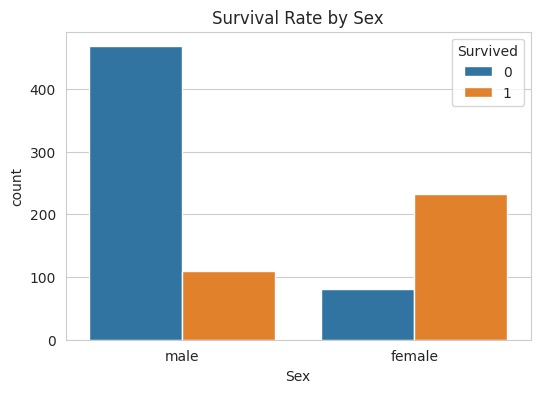

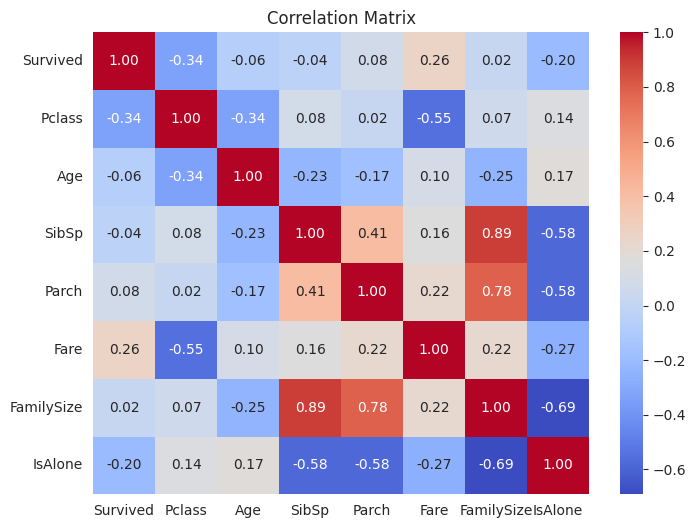

In [ ]:
# Survival by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### 5. Data Transformation for Modeling

In [ ]:
# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Preprocessing setup
numerical_features = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch', 'IsAlone']
categorical_features = ['Pclass', 'Sex', 'Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply transformations
X_transformed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding and create DataFrame
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(onehot_feature_names)
X = pd.DataFrame(X_transformed, columns=all_feature_names)

print("Transformed data (first 3 rows):")
display(X.head(3))

Transformed data (first 3 rows):


,Age,Fare,FamilySize,SibSp,Parch,IsAlone,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,-0.565736,-0.502445,0.059160,0.432793,-0.473674,-1.231645,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.663861,0.786845,0.059160,0.432793,-0.473674,-1.231645,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.258337,-0.488854,-0.560975,-0.474545,-0.473674,0.811922,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


### 6. Model Building and Evaluation

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Model Accuracy: 0.7933

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       105
           1       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

